# 買い目しきい値 ±0.10 の最適化検証

## 目的

現状の買い目は **1マーク予想の走行距離** を基準に、各着順の上位艇から **±0.10 以内**の艇を
候補に入れている。この `±0.10`(`one-mark-distance.ts` の `TOLERANCE`)は根拠のない経験則。
本ノートでは実払戻(`results/payouts` の3連単)で**回収率(ROI)を最大化するしきい値**を探索する。

- 対象予想者: **v1_basic**
- 状態: **realtime(直前情報反映後)**
- 期間: **2026-05**(強さpt `estimate/v1_basic` が存在する唯一の期間)
- 目的関数: **回収率 = 払戻合計 / 賭け金合計**(1点 ¥100、フォーメーション総点買い)
- しきい値構造: **着順ごとに別々**(1着=`t1` / 2着=`t2` / 3着=`t3`)

## 結論サマリ(先出し)

1. 現行 `±0.10/0.10/0.10` の全期間ROIは **約74%**。しきい値調整でROIは改善できるが、
   **どの設定でも100%(損益分岐)には届かない** — 3連単の控除率を覆すしきい値は存在しない。
   しきい値最適化は「勝てる買い目を作る」ではなく「**負けを小さくする**」問題。
2. 全期間ROIを単純最大化すると `t1=0.16, t2=0.00, t3=0.12`(ROI約83%)だが、
   **前半/後半の時間分割で激しく過学習**(片側97%→反対側65%)。そのまま採用は危険。
3. **両半期で安定して良い**ロバストな設定は **`t1=0.02, t2=0.10, t3=0.20`**(全期間ROI約78%、
   前後半とも約78%)。現行比 **+約4pt(全期間)/ +約7pt(弱い側)**、的中率は同等(約41%)、
   平均点数はむしろ減少(12.4→10.6点)。
4. 構造的な示唆: **1着候補は絞り(t1小)、3着候補は広げる(t3大)**方向が効く。
   1着は荒れにくく軸が立ちやすい一方、3着は荒れるため広く取る方が拾える。


In [1]:
import warnings
from pathlib import Path
from itertools import product
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # noqa
except Exception:
    pass
warnings.simplefilter("ignore")
pd.set_option("display.width", 160)

def find_data_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "results" / "realtime").is_dir():
            return p
    raise FileNotFoundError("data/ が見つかりません")

ROOT = find_data_root(Path.cwd())
print("ROOT =", ROOT)

ROOT = /sessions/sleepy-elegant-cerf/mnt/boatracecsv.github.io


## 1. データ読込と結合

`one-mark-distance.ts` の走行距離をそのまま再現するために、4つのCSVを `レースコード` で結合する。

| データ | カラム | 用途 |
| --- | --- | --- |
| `programs/race_cards` | `艇N_全国平均ST` | 走行距離の `avgST` |
| `estimate/v1_basic`(状態=realtime) | `N枠_強さpt` | 走行距離の `strengthPt` |
| `results/realtime` | `1〜3着_艇番` | 的中判定 |
| `results/payouts` | `3連単_払戻金` | 回収率 |

> 走行距離 `distance = (1 - 全国平均ST) + 強さpt / 50 - 1.6`(`computeOneMarkDistances` と同一)


In [2]:
def load_strength():
    files = sorted((ROOT/"data/estimate/v1_basic/2026/05").glob("*.csv"))
    est = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)
    cols = [f"{i}枠_強さpt" for i in range(1, 7)]
    for c in cols: est[c] = pd.to_numeric(est[c], errors="coerce")
    est = est[est["状態"] == "realtime"].drop_duplicates("レースコード", keep="last")
    est["pt"] = est[cols].values.tolist()
    return est[["レースコード", "pt"]]

def load_st():
    files = sorted((ROOT/"data/programs/race_cards/2026/05").glob("*.csv"))
    rc = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)
    cols = [f"艇{i}_全国平均ST" for i in range(1, 7)]
    for c in cols: rc[c] = pd.to_numeric(rc[c], errors="coerce")
    rc = rc.drop_duplicates("レースコード", keep="last")
    rc["st"] = rc[cols].values.tolist()
    return rc[["レースコード", "st"]]

def load_result():
    files = sorted((ROOT/"data/results/realtime/2026/05").glob("*.csv"))
    df = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)
    for k in range(1, 4): df[f"{k}着_艇番"] = pd.to_numeric(df[f"{k}着_艇番"], errors="coerce")
    df["top3"] = df[[f"{k}着_艇番" for k in range(1, 4)]].values.tolist()
    return df[["レースコード", "レース日", "top3"]]

def load_pay():
    files = sorted((ROOT/"data/results/payouts/2026/05").glob("*.csv"))
    pay = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)
    pay["払戻"] = pd.to_numeric(pay["3連単_払戻金"], errors="coerce")
    return pay.drop_duplicates("レースコード", keep="last")[["レースコード", "払戻"]]

strength, st, res, pay = load_strength(), load_st(), load_result(), load_pay()
df = strength.merge(st, on="レースコード").merge(res, on="レースコード").merge(pay, on="レースコード")
print(f"結合レース数: {len(df)}")

結合レース数: 3473


In [3]:
# 走行距離を計算し、欠損のない有効レースに絞る
def to_dist(row):
    pt = np.array(row["pt"], float); stv = np.array(row["st"], float)
    return (1 - stv) + pt/50 - 1.6

df["dist"] = df.apply(to_dist, axis=1)

def valid(row):
    d = row["dist"]; t = row["top3"]
    top_ok = all(x is not None and not (isinstance(x, float) and np.isnan(x)) for x in t)
    return (not np.any(np.isnan(d))) and top_ok and not np.isnan(row["払戻"])

df = df[df.apply(valid, axis=1)].reset_index(drop=True)
print(f"有効レース数: {len(df)} | 期間: {df['レース日'].min()} 〜 {df['レース日'].max()}")

有効レース数: 3461 | 期間: 2026-05-01 〜 2026-05-30


## 2. 買い目ロジックの再現(着順別しきい値)

`computeBettingPicks` と同じく、走行距離降順で上位3艇を基準点とし、
各基準点 ±t 以内の艇を候補にする。違いは **着順ごとに別々のしきい値** `t1/t2/t3` を許す点。

- 1着候補: 距離最大艇の距離 ±`t1`
- 2着候補: 距離2位艇の距離 ±`t2`
- 3着候補: 距離3位艇の距離 ±`t3`

賭け点数・的中判定は `bet-payout.ts` / `bet-hit.ts` に揃える(1-2-3着で同一艇番の重複出目は除外)。
全レース一括をベクトル化して評価する。


In [4]:
D = np.vstack(df["dist"].values)                              # (N,6) 各艇の走行距離
T = np.array([[int(x) for x in t] for t in df["top3"].values])  # (N,3) 実際の1〜3着 艇番
PAY = df["払戻"].values.astype(float)
DATES = df["レース日"].values
N = len(df)
order = np.argsort(-D, axis=1)
ref1 = D[np.arange(N), order[:, 0]]   # 1位の距離
ref2 = D[np.arange(N), order[:, 1]]   # 2位の距離
ref3 = D[np.arange(N), order[:, 2]]   # 3位の距離

def evaluate(t1, t2, t3, mask=None):
    # しきい値(t1,t2,t3)でのROI/的中率/平均点数を返す。mask で期間を限定可能。
    f  = np.abs(D - ref1[:, None]) <= t1 + 1e-9
    s  = np.abs(D - ref2[:, None]) <= t2 + 1e-9
    th = np.abs(D - ref3[:, None]) <= t3 + 1e-9
    nf, ns, nt = f.sum(1), s.sum(1), th.sum(1)
    fs, ft, st_, fst = (f&s).sum(1), (f&th).sum(1), (s&th).sum(1), (f&s&th).sum(1)
    # 1着in f, 2着in s, 3着in th で3艇すべて相異なる組合せ数(包除原理)
    cnt = nf*ns*nt - fs*nt - ft*ns - st_*nf + 2*fst
    hit = (f[np.arange(N), T[:,0]-1] & s[np.arange(N), T[:,1]-1] & th[np.arange(N), T[:,2]-1]
           & (T[:,0]!=T[:,1]) & (T[:,1]!=T[:,2]) & (T[:,0]!=T[:,2]))
    valid = cnt > 0
    if mask is not None: valid = valid & mask
    n = int(valid.sum())
    cost = (cnt[valid] * 100).sum()
    h = hit & valid
    roi = PAY[h].sum() / cost * 100 if cost else 0.0
    return dict(roi=roi, hit=h.sum()/n*100 if n else 0, avgpts=cnt[valid].mean() if n else 0,
                n=n, hits=int(h.sum()))

base = evaluate(0.10, 0.10, 0.10)
print("現行 ±0.10/0.10/0.10 →", {k: round(v,2) if isinstance(v,float) else v for k,v in base.items()})

現行 ±0.10/0.10/0.10 → {'roi': np.float64(74.4), 'hit': np.float64(40.8), 'avgpts': np.float64(12.37), 'n': 3461, 'hits': 1412}


## 3. しきい値グリッドサーチ(全期間ROI)

`t1,t2,t3` を 0.00〜0.40(0.02刻み、各21点 → 9,261通り)で総当たりし、全期間ROIを評価する。


In [5]:
grid = np.round(np.arange(0.0, 0.42, 0.02), 2)
rows = []
for t1, t2, t3 in product(grid, grid, grid):
    r = evaluate(t1, t2, t3)
    if r["n"] < N*0.85:   # 候補が立たないレースが多すぎる設定は除外
        continue
    rows.append((t1, t2, t3, r["roi"], r["hit"], r["avgpts"], r["n"]))
G = pd.DataFrame(rows, columns=["t1","t2","t3","roi","hit","avgpts","n"])
print(f"評価した設定数: {len(G)}")
print("\n=== 全期間ROI 上位10 ===")
print(G.sort_values("roi", ascending=False).head(10).to_string(index=False))

評価した設定数: 9261

=== 全期間ROI 上位10 ===
  t1   t2   t3       roi       hit   avgpts    n
0.16 0.00 0.12 82.802674 18.578446 5.099971 3461
0.16 0.00 0.14 82.033038 19.445247 5.632187 3461
0.14 0.00 0.12 81.188714 18.231725 4.567177 3461
0.16 0.00 0.20 80.850549 21.207743 6.573245 3461
0.16 0.00 0.16 80.655574 20.138688 6.060098 3461
0.22 0.02 0.00 80.542016  8.350188 2.276221 3461
0.02 0.10 0.00 79.879343 10.777232 1.987576 3461
0.16 0.00 0.18 79.853981 20.629876 6.331985 3461
0.04 0.08 0.00 79.620054 10.314938 1.832707 3461
0.14 0.00 0.20 79.581745 20.629876 5.761341 3461


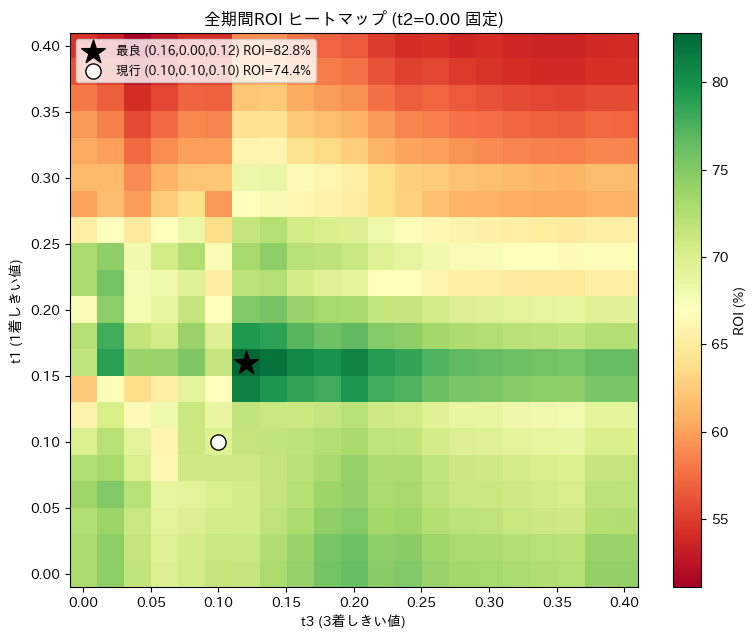

In [6]:
# ヒートマップ: 全期間ROIを最大化する t2 に固定し、t1×t3 面を描く
best_row = G.sort_values("roi", ascending=False).iloc[0]
fix_t2 = best_row["t2"]
piv = (G[np.isclose(G["t2"], fix_t2)]
       .pivot(index="t1", columns="t3", values="roi"))
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(piv.values, origin="lower", aspect="auto", cmap="RdYlGn",
               extent=[piv.columns.min()-.01, piv.columns.max()+.01,
                       piv.index.min()-.01, piv.index.max()+.01])
ax.set_xlabel("t3 (3着しきい値)"); ax.set_ylabel("t1 (1着しきい値)")
ax.set_title(f"全期間ROI ヒートマップ (t2={fix_t2:.2f} 固定)")
ax.scatter([best_row['t3']],[best_row['t1']], marker="*", s=320, c="black",
           label=f"最良 ({best_row['t1']:.2f},{fix_t2:.2f},{best_row['t3']:.2f}) ROI={best_row['roi']:.1f}%")
ax.scatter([0.10],[0.10], marker="o", s=120, edgecolor="black", facecolor="white",
           label=f"現行 (0.10,0.10,0.10) ROI={base['roi']:.1f}%")
ax.legend(loc="upper left", fontsize=9)
plt.colorbar(im, label="ROI (%)"); plt.tight_layout(); plt.show()

## 4. 過学習の検証(時間分割ホールドアウト)

上の「全期間ROI最大」は **同じデータで探索して同じデータで評価**しているため過学習している。
期間を**前半/後半に分割**し、片方で選んだ最適しきい値を**もう片方**で評価して汎化性能を見る。


In [7]:
uniq = np.sort(np.unique(DATES))
mid = uniq[len(uniq)//2]
mask_a = DATES < mid      # 前半
mask_b = DATES >= mid     # 後半
print(f"前半 < {mid}: {mask_a.sum()}R / 後半 >= {mid}: {mask_b.sum()}R")

def best_on(mask):
    best = None
    for t1, t2, t3 in product(grid, grid, grid):
        r = evaluate(t1, t2, t3, mask)
        if r["n"] < mask.sum()*0.85: continue
        if best is None or r["roi"] > best["roi"]:
            best = dict(t1=t1, t2=t2, t3=t3, **r)
    return best

ba, bb = best_on(mask_a), best_on(mask_b)
print(f"\n前半で最適: ({ba['t1']},{ba['t2']},{ba['t3']}) 前半ROI={ba['roi']:.1f}% "
      f"→ 後半で評価 ROI={evaluate(ba['t1'],ba['t2'],ba['t3'],mask_b)['roi']:.1f}%")
print(f"後半で最適: ({bb['t1']},{bb['t2']},{bb['t3']}) 後半ROI={bb['roi']:.1f}% "
      f"→ 前半で評価 ROI={evaluate(bb['t1'],bb['t2'],bb['t3'],mask_a)['roi']:.1f}%")
print(f"\n現行0.10:  前半ROI={evaluate(0.1,0.1,0.1,mask_a)['roi']:.1f}% / "
      f"後半ROI={evaluate(0.1,0.1,0.1,mask_b)['roi']:.1f}%")
print("→ 単純なROI最大しきい値は反対期間で大きく崩れる(過学習)。現行0.10の方が安定。")

前半 < 2026-05-17: 1647R / 後半 >= 2026-05-17: 1814R



前半で最適: (0.14,0.0,0.12) 前半ROI=97.2% → 後半で評価 ROI=65.3%
後半で最適: (0.24,0.02,0.0) 後半ROI=105.3% → 前半で評価 ROI=53.1%

現行0.10:  前半ROI=77.6% / 後半ROI=71.1%
→ 単純なROI最大しきい値は反対期間で大きく崩れる(過学習)。現行0.10の方が安定。


## 5. ロバストなしきい値の選定

単純な全期間最大ではなく、**前半ROIと後半ROIの小さい方(min)を最大化**する設定を選ぶ。
「どの時期でも一定以上」を担保するロバスト基準。


In [8]:
rows2 = []
for t1, t2, t3 in product(grid, grid, grid):
    ra = evaluate(t1, t2, t3, mask_a)
    rb = evaluate(t1, t2, t3, mask_b)
    allr = evaluate(t1, t2, t3)
    if allr["n"] < N*0.85: continue
    rows2.append((t1, t2, t3, allr["roi"], min(ra["roi"], rb["roi"]),
                  ra["roi"], rb["roi"], allr["hit"], allr["avgpts"]))
R = pd.DataFrame(rows2, columns=["t1","t2","t3","roi_all","roi_min","roi_前半","roi_後半","hit","avgpts"])
print("=== ロバスト基準(両期間ROIの最小値)上位8 ===")
print(R.sort_values("roi_min", ascending=False).head(8).to_string(index=False))

rec = R.sort_values("roi_min", ascending=False).iloc[0]
print(f"\n>>> 推奨しきい値: t1={rec['t1']:.2f}, t2={rec['t2']:.2f}, t3={rec['t3']:.2f}")

=== ロバスト基準(両期間ROIの最小値)上位8 ===
  t1   t2   t3   roi_all   roi_min    roi_前半    roi_後半       hit    avgpts
0.02 0.10 0.20 78.139916 77.795048 77.795048 78.485727 41.490899 10.581335
0.04 0.10 0.06 78.649140 77.598466 79.687419 77.598466 29.182317  6.671193
0.08 0.12 0.06 77.700834 77.402078 78.002108 77.402078 33.776365  9.358567
0.08 0.12 0.02 77.161480 76.997078 77.327154 76.997078 20.832129  5.319561
0.06 0.12 0.02 76.978967 76.913080 76.913080 77.045155 20.167582  4.835597
0.16 0.00 0.02 78.938482 76.900206 76.900206 80.966608  9.794857  1.967928
0.02 0.10 0.22 77.225460 76.813421 76.813421 77.638223 41.779832 10.858422
0.02 0.10 0.08 77.134527 76.689678 77.566661 76.689678 31.696042  7.134932

>>> 推奨しきい値: t1=0.02, t2=0.10, t3=0.20


In [9]:
# 現行 vs 全期間最大 vs ロバスト推奨 の比較
cur = evaluate(0.10, 0.10, 0.10)
top = G.sort_values("roi", ascending=False).iloc[0]
opt = evaluate(top["t1"], top["t2"], top["t3"])
rb_ = evaluate(rec["t1"], rec["t2"], rec["t3"])
comp = pd.DataFrame([
    ["現行 (0.10,0.10,0.10)", cur["roi"], cur["hit"], cur["avgpts"],
        evaluate(.1,.1,.1,mask_a)["roi"], evaluate(.1,.1,.1,mask_b)["roi"]],
    [f"全期間ROI最大 ({top['t1']:.2f},{top['t2']:.2f},{top['t3']:.2f})", opt["roi"], opt["hit"], opt["avgpts"],
        evaluate(top['t1'],top['t2'],top['t3'],mask_a)["roi"], evaluate(top['t1'],top['t2'],top['t3'],mask_b)["roi"]],
    [f"ロバスト推奨 ({rec['t1']:.2f},{rec['t2']:.2f},{rec['t3']:.2f})", rb_["roi"], rb_["hit"], rb_["avgpts"],
        evaluate(rec['t1'],rec['t2'],rec['t3'],mask_a)["roi"], evaluate(rec['t1'],rec['t2'],rec['t3'],mask_b)["roi"]],
], columns=["設定","全期間ROI%","的中率%","平均点数","前半ROI%","後半ROI%"]).round(2)
comp

,設定,全期間ROI%,的中率%,平均点数,前半ROI%,後半ROI%
0,"現行 (0.10,0.10,0.10)",74.40,40.80,12.37,77.6,71.14
1,"全期間ROI最大 (0.16,0.00,0.12)",82.80,18.58,5.10,90.4,75.21
2,"ロバスト推奨 (0.02,0.10,0.20)",78.14,41.49,10.58,77.8,78.49


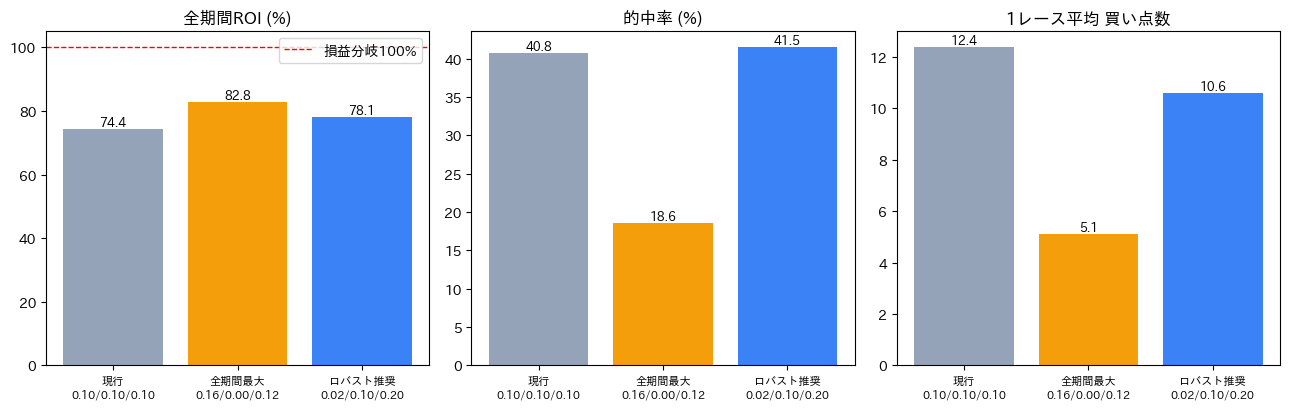

In [10]:
# 比較バーチャート
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
labels = ["現行\n0.10/0.10/0.10",
          f"全期間最大\n{top['t1']:.2f}/{top['t2']:.2f}/{top['t3']:.2f}",
          f"ロバスト推奨\n{rec['t1']:.2f}/{rec['t2']:.2f}/{rec['t3']:.2f}"]
colors = ["#94a3b8", "#f59e0b", "#3b82f6"]
for ax, key, title, ref in [
    (axes[0], "全期間ROI%", "全期間ROI (%)", 100),
    (axes[1], "的中率%", "的中率 (%)", None),
    (axes[2], "平均点数", "1レース平均 買い点数", None)]:
    ax.bar(labels, comp[key], color=colors)
    if ref: ax.axhline(ref, ls="--", c="red", lw=1, label="損益分岐100%"); ax.legend()
    ax.set_title(title)
    for i, v in enumerate(comp[key]): ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

## 6. 結論と注意

### 分かったこと

- **`±0.10` は最適ではない**。着順別しきい値にすると改善余地がある。全期間ROIだけ見れば
  `t1=0.16, t2=0.00, t3=0.12` で約83%まで上がるが、**これは過学習**で別期間では崩れる。
- **ロバスト推奨は `t1≈0.02 / t2≈0.10 / t3≈0.20`**。前後半どちらでも約78%で安定し、現行(弱い側71%)を
  明確に上回る。的中率は現行同等(約41%)、平均買い点数はむしろ減る(12.4→10.6点)。
- 構造的には **「1着は絞る・3着は広げる」** が効く。1着は堅く軸が立つので無駄玉を減らし、
  3着は荒れるので広く拾う、という直感と一致する。

### 重要な注意

- **どの設定でもROIは100%未満**。これは3連単の控除率(約25%)を、走行距離ベースの
  買い目だけでは覆せないことを意味する。しきい値最適化は「**負けを小さくする**」調整であり、
  これ単体で勝てる戦略にはならない。利益を狙うなら期待値(オッズ)を絡めた絞り込みが別途必要。
- **データは2026年5月の約3,461レースのみ**(強さ pt が存在する唯一の期間)。サンプルが小さく、
  季節・開催種別の偏りもあり得る。**過学習リスクは高い**。本ノートの推奨値は
  「現行より無難」程度に受け止め、**データが増えたら再探索**するのが安全。
- 反映する場合は `one-mark-distance.ts` の `TOLERANCE` 単一定数を、着順別の3定数
  (例 `TOLERANCE_FIRST/SECOND/THIRD`)に分け、`computeBettingPicks` の各 `pickWithin` に
  対応するしきい値を渡す形になる(本ノートの `evaluate` と同じ構造)。
